
# Marathi–Hindi Data Preparation for Graformer Training

This notebook helps prepare a Marathi–Hindi parallel dataset for Graformer/Fairseq multilingual training.

It covers:

1. Dataset inspection
2. Cleaning and filtering
3. Length statistics
4. SentencePiece vocabulary training
5. Vocabulary-size exploration
6. Binarization for Fairseq/Graformer
7. Final directory structure verification
8. Training command generation

Expected files:

```bash
/mnt/storage/divya/train.hi
/mnt/storage/divya/train.mr
```


In [1]:

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import sentencepiece as spm
import subprocess
import numpy as np

DATA_DIR = r"C:\Users\USER\Downloads\IIT-Delhi-MISN-Lab-Adivaani-Hindi-Marathi-Dataset-Hiring-2026-20260511T103428Z-3-001\IIT-Delhi-MISN-Lab-Adivaani-Hindi-Marathi-Dataset-Hiring-2026"

hi_file = os.path.join(DATA_DIR, "train.hi")
mr_file = os.path.join(DATA_DIR, "train.mr")

test_hi_file = os.path.join(DATA_DIR, "test.hi")
test_mr_file = os.path.join(DATA_DIR, "test.mr")

print("Hindi file:", hi_file)
print("Marathi file:", mr_file)

assert os.path.exists(hi_file)
assert os.path.exists(mr_file)

assert os.path.exists(test_hi_file)
assert os.path.exists(test_mr_file)
print("Files found.")


Hindi file: C:\Users\USER\Downloads\IIT-Delhi-MISN-Lab-Adivaani-Hindi-Marathi-Dataset-Hiring-2026-20260511T103428Z-3-001\IIT-Delhi-MISN-Lab-Adivaani-Hindi-Marathi-Dataset-Hiring-2026\train.hi
Marathi file: C:\Users\USER\Downloads\IIT-Delhi-MISN-Lab-Adivaani-Hindi-Marathi-Dataset-Hiring-2026-20260511T103428Z-3-001\IIT-Delhi-MISN-Lab-Adivaani-Hindi-Marathi-Dataset-Hiring-2026\train.mr
Files found.


## Load Parallel Corpus

In [4]:

with open(hi_file, encoding="utf-8") as f:
    hi_lines = [x.strip() for x in f.readlines()]

with open(mr_file, encoding="utf-8") as f:
    mr_lines = [x.strip() for x in f.readlines()]

print("Hindi sentences:", len(hi_lines))
print("Marathi sentences:", len(mr_lines))

assert len(hi_lines) == len(mr_lines)

df = pd.DataFrame({
    "hi": hi_lines,
    "mr": mr_lines
})

df.head()


Hindi sentences: 241847
Marathi sentences: 241847


,hi,mr
0,इस प्रयोग को नित्य करने से दाँत नहीं स...,हा प्रयोग रोज केल्याने दात खराब होत नाह...
1,मध्यकाल में माना जाता था कि जिसके पास ...,ज्याच्याजवळ जितकी काळी मिरी तितका तो जास...
2,हिमाचल पर्यटन के दौरान आमतौर पर सैलानियों के द...,हिमाचल पर्यटनाच्या दरम्यान साधारणपणे पर्य...
3,अरुणाचल प्रदेश की जनसंख्या ( सन् 2001 म...,अरुणाचल प्रदेशची लोकसंख्या ( 2001 साली ...
4,सच मानिए तो दिल्ली अपने आप में एक पूरा...,खरे बघता दिल्ली खरोखरीच एक परिपूर्ण पर्य...


## Basic Cleaning

In [5]:

def valid_pair(row):
    if len(row["hi"]) == 0 or len(row["mr"]) == 0:
        return False
    
    hi_len = len(row["hi"].split())
    mr_len = len(row["mr"].split())
    
    if hi_len < 1 or mr_len < 1:
        return False
    
    if hi_len > 250 or mr_len > 250:
        return False
    
    ratio = max(hi_len/mr_len, mr_len/hi_len)
    
    if ratio > 3:
        return False
    
    return True

clean_df = df[df.apply(valid_pair, axis=1)].reset_index(drop=True)

print("Original pairs:", len(df))
print("Clean pairs:", len(clean_df))


Original pairs: 241847
Clean pairs: 240696


## Sentence Length Analysis

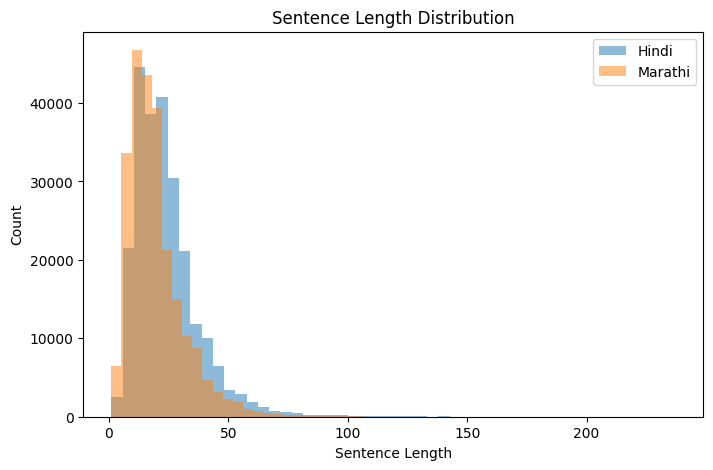

              hi_len         mr_len
count  240696.000000  240696.000000
mean       24.049797      19.444789
std        14.099796      12.039573
min         1.000000       1.000000
25%        15.000000      11.000000
50%        21.000000      16.000000
75%        30.000000      24.000000
max       237.000000     213.000000


In [6]:

clean_df["hi_len"] = clean_df["hi"].apply(lambda x: len(x.split()))
clean_df["mr_len"] = clean_df["mr"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(clean_df["hi_len"], bins=50, alpha=0.5, label="Hindi")
plt.hist(clean_df["mr_len"], bins=50, alpha=0.5, label="Marathi")
plt.legend()
plt.xlabel("Sentence Length")
plt.ylabel("Count")
plt.title("Sentence Length Distribution")
plt.show()

print(clean_df[["hi_len","mr_len"]].describe())



## Save Cleaned Corpus

These files will be used for SentencePiece training.


In [8]:

prep_dir = Path("./prepared_data")
prep_dir.mkdir(exist_ok=True)

clean_hi = prep_dir / "clean.train.hi"
clean_mr = prep_dir / "clean.train.mr"

with open(clean_hi, "w", encoding="utf-8") as f:
    f.write("\n".join(clean_df["hi"]))

with open(clean_mr, "w", encoding="utf-8") as f:
    f.write("\n".join(clean_df["mr"]))

print("Saved cleaned corpus.")


Saved cleaned corpus.



# Vocabulary Exploration

We evaluate multiple vocabulary sizes and inspect subword fragmentation.


In [10]:

vocab_sizes = [4000, 8000, 16000, 32000]

results = []

combined_file = prep_dir / "combined.txt"

with open(combined_file, "w", encoding="utf-8") as out:
    for line in clean_df["hi"]:
        out.write(line + "\n")
    for line in clean_df["mr"]:
        out.write(line + "\n")

for vocab in vocab_sizes:
    
    prefix = prep_dir / f"spm_{vocab}"
    
    spm.SentencePieceTrainer.train(
        input=str(combined_file),
        model_prefix=str(prefix),
        vocab_size=vocab,
        model_type="unigram",
        character_coverage=0.9995
    )
    
    sp = spm.SentencePieceProcessor()
    sp.load(str(prefix) + ".model")
    
    sample = clean_df.sample(min(1000, len(clean_df)))
    
    pieces = []
    for text in sample["hi"].tolist() + sample["mr"].tolist():
        pieces.extend(sp.encode_as_pieces(text))
    
    avg_pieces = np.mean([len(x) for x in pieces])
    unique_pieces = len(set(pieces))
    
    results.append({
        "vocab_size": vocab,
        "avg_subword_length": avg_pieces,
        "unique_subwords": unique_pieces
    })

results_df = pd.DataFrame(results)
results_df


,vocab_size,avg_subword_length,unique_subwords
0,4000,3.560518,3809
1,8000,4.068250,6548
2,16000,4.416225,9168
3,32000,4.680069,10479



## Recommended Vocabulary Size

General recommendation:

| Dataset Size | Recommended Vocab |
|---|---|
| <1M sentences | 8k |
| 1M–10M | 16k |
| >10M | 32k |

For Marathi–Hindi:
- 8k → strong sharing and compact model
- 16k → best balance
- 32k → better fluency for very large corpora



# Final SentencePiece Training

Adjust `FINAL_VOCAB_SIZE` if needed.


In [11]:

FINAL_VOCAB_SIZE = 8000

final_prefix = prep_dir / "spm_final"

spm.SentencePieceTrainer.train(
    input=str(combined_file),
    model_prefix=str(final_prefix),
    vocab_size=FINAL_VOCAB_SIZE,
    model_type="unigram",
    character_coverage=0.9995
)

print("Final tokenizer trained.")


Final tokenizer trained.


## Encode Dataset Using SentencePiece

In [ ]:

sp = spm.SentencePieceProcessor()
sp.load(str(final_prefix) + ".model")

def encode_file(input_file, output_file):
    with open(input_file, encoding="utf-8") as fin, open(output_file, "w", encoding="utf-8") as fout:
        for line in fin:
            pieces = sp.encode_as_pieces(line.strip())
            fout.write(" ".join(pieces) + "\n")

encode_file(clean_hi, prep_dir / "spm.train.hi")
encode_file(clean_mr, prep_dir / "spm.train.mr")


print("Tokenized files saved.")


Tokenized files saved.


In [ ]:
head -1000 train.spm.hi > valid.spm.hi
head -1000 train.spm.mr > valid.spm.mr

tail -n +1001 train.spm.hi > train_final.spm.hi
tail -n +1001 train.spm.mr > train_final.spm.mr


# Fairseq/Graformer Preprocessing

Run this command in terminal:

```bash
fairseq-preprocess     --source-lang mr     --target-lang hi     --trainpref prepared_data/spm.train     --destdir prepared_data/data-bin     --workers 8     --srcdict prepared_data/spm_final.vocab     --tgtdict prepared_data/spm_final.vocab
```

If shared vocabulary causes issues:

```bash
fairseq-preprocess     --source-lang mr     --target-lang hi     --trainpref prepared_data/spm.train     --destdir prepared_data/data-bin     --workers 8
```



# Expected Final Structure

```bash
prepared_data/
├── clean.train.hi
├── clean.train.mr
├── spm.train.hi
├── spm.train.mr
├── spm_final.model
├── spm_final.vocab
└── data-bin/
    ├── dict.hi.txt
    ├── dict.mr.txt
    ├── train.hi-mr.hi.bin
    ├── train.hi-mr.hi.idx
    ├── train.hi-mr.mr.bin
    └── train.hi-mr.mr.idx
```



# Graformer Training Notes

For small datasets:
- reduce max tokens
- use smaller update frequency
- lower dropout

Recommended initial settings:

```bash
--max-tokens 2048
--update-freq 2
--dropout 0.2
```

For larger corpora:
- vocab=16000
- max-tokens=4000–8000
- fp16 enabled
